In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2  import preprocess_input
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
train_dir = "../smartvision_dataset/classification/train"
val_dir = "../smartvision_dataset/classification/val"
test_dir = "../smartvision_dataset/classification/test"

In [3]:
img_size = (224, 224)
batch_size = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle= False
)

Found 1749 images belonging to 25 classes.
Found 375 images belonging to 25 classes.
Found 375 images belonging to 25 classes.


In [4]:
num_classes = train_data.num_classes

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

for layer in base_model.layers[:-20]:
    layer.trainable = False

for layer in base_model.layers[-20:]:
    layer.trainable = True

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation='relu',
                 kernel_regularizer=tf.keras.regularizers.l2(0.001))(x)
x = layers.Dropout(0.4)(x)
output = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=output)

In [5]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [6]:
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(factor=0.3, patience=3),
    ModelCheckpoint("../models/mobilenet_model.h5", save_best_only=True)
]

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=50,
    callbacks=callbacks
)

Epoch 1/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.0997 - loss: 4.0448

55/55 ━━━━━━━━━━━━━━━━━━━━ 96s 2s/step - accuracy: 0.1544 - loss: 3.6632 - val_accuracy: 0.2907 - val_loss: 2.9447 - learning_rate: 1.0000e-04
Epoch 2/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3946 - loss: 2.5276

55/55 ━━━━━━━━━━━━━━━━━━━━ 87s 2s/step - accuracy: 0.4197 - loss: 2.3919 - val_accuracy: 0.4507 - val_loss: 2.3564 - learning_rate: 1.0000e-04
Epoch 3/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5147 - loss: 1.9760

55/55 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 0.5357 - loss: 1.9162 - val_accuracy: 0.5067 - val_loss: 2.0428 - learning_rate: 1.0000e-04
Epoch 4/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6312 - loss: 1.6103

55/55 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step - accuracy: 0.6278 - loss: 1.6064 - val_accuracy: 0.5813 - val_loss: 1.8524 - learning_rate: 1.0000e-04
Epoch 5/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6807 - loss: 1.3972

...

55/55 ━━━━━━━━━━━━━━━━━━━━ 87s 2s/step - accuracy: 0.8250 - loss: 0.9235 - val_accuracy: 0.6880 - val_loss: 1.4586 - learning_rate: 1.0000e-04
Epoch 10/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8276 - loss: 0.8823

55/55 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - accuracy: 0.8193 - loss: 0.8886 - val_accuracy: 0.7040 - val_loss: 1.4236 - learning_rate: 1.0000e-04
Epoch 11/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8311 - loss: 0.8339

55/55 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 0.8302 - loss: 0.8289 - val_accuracy: 0.7147 - val_loss: 1.3982 - learning_rate: 1.0000e-04
Epoch 12/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.8571 - loss: 0.7815 - val_accuracy: 0.7173 - val_loss: 1.4154 - learning_rate: 1.0000e-04
Epoch 13/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.8788 - loss: 0.6962 - val_accuracy: 0.7307 - val_loss: 1.4784 - learning_rate: 1.0000e-04
Epoch 14/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8900 - loss: 0.6591

55/55 ━━━━━━━━━━━━━━━━━━━━ 87s 2s/step - accuracy: 0.8805 - loss: 0.6740 - val_accuracy: 0.7360 - val_loss: 1.3887 - learning_rate: 1.0000e-04
Epoch 15/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8731 - loss: 0.6873

55/55 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step - accuracy: 0.8759 - loss: 0.6603 - val_accuracy: 0.7627 - val_loss: 1.3139 - learning_rate: 1.0000e-04
Epoch 16/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 0.9102 - loss: 0.5993 - val_accuracy: 0.7413 - val_loss: 1.4176 - learning_rate: 1.0000e-04
Epoch 17/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.9160 - loss: 0.5683 - val_accuracy: 0.7600 - val_loss: 1.3587 - learning_rate: 1.0000e-04
Epoch 18/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.9045 - loss: 0.5846 - val_accuracy: 0.7707 - val_loss: 1.3368 - learning_rate: 1.0000e-04
Epoch 19/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.9228 - loss: 0.5235 - val_accuracy: 0.7760 - val_loss: 1.3144 - learning_rate: 3.0000e-05
Epoch 20/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.9188 - loss: 0.5173 - val_accuracy: 0.7627 - val_loss: 1.3185 - learning_rate: 3.0000e-05


- Train Accuracy is 91

In [7]:
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)

12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 875ms/step - accuracy: 0.7813 - loss: 1.2107
Test Accuracy: 0.781333327293396


- Test acuuracy is 78

In [ ]:
def prediction():
    model = models.load_model("../models/mobilenet_model.h5")
    img_path = "../smartvision_dataset/classification/test/bottle/bottle_test_0000.jpg"

    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array) 

    predictions = model.predict(img_array)
    class_indices = train_data.class_indices
    class_names = list(class_indices.keys())

    predicted_class = class_names[np.argmax(predictions)]
    return predicted_class

In [8]:
pred = prediction()
pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


'bottle'

In [9]:
model = models.load_model("../models/mobilenet_model.h5")
y_pred = model.predict(test_data)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_data.classes
print(classification_report(y_true, y_pred_classes, target_names=list(test_data.class_indices.keys())))

12/12 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step
               precision    recall  f1-score   support

     airplane       1.00      0.87      0.93        15
          bed       1.00      0.53      0.70        15
        bench       1.00      0.40      0.57        15
      bicycle       0.93      0.93      0.93        15
         bird       1.00      0.80      0.89        15
       bottle       0.71      0.67      0.69        15
         bowl       1.00      0.80      0.89        15
          bus       1.00      0.80      0.89        15
         cake       1.00      0.87      0.93        15
          car       0.88      0.93      0.90        15
          cat       1.00      0.73      0.85        15
        chair       0.92      0.80      0.86        15
        couch       0.38      1.00      0.55        15
          cow       1.00      0.87      0.93        15
          cup       1.00      0.60      0.75        15
          dog       1.00      0.93      0.97        15
     elephant       1.00 

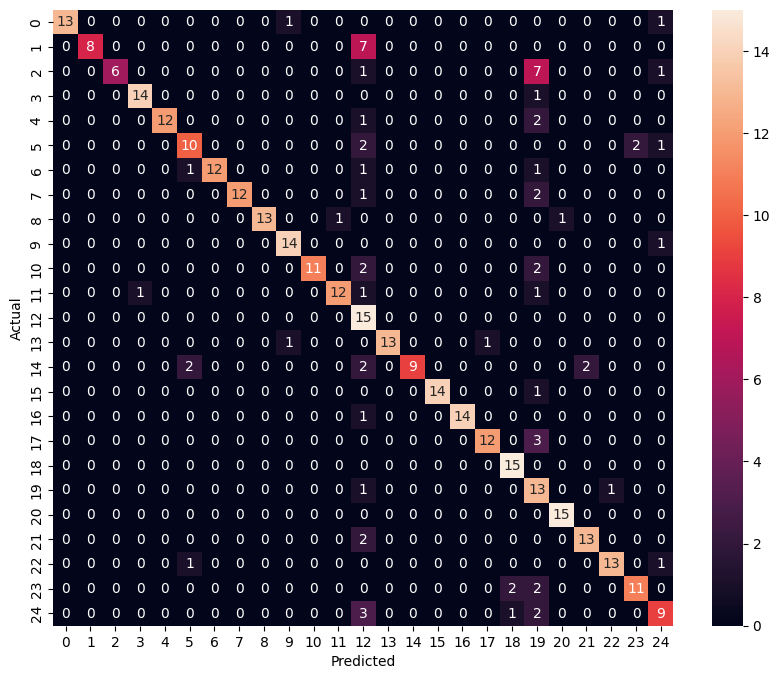

In [10]:
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()